# Flight Price Prediction

Trying to predict flight ticket prices using the features given (airline, source/destination, stops, duration, days left before departure etc).

Plan:
1. Load data, check dtypes and basic stats
2. Clean up missing values / duplicates / outliers
3. Some EDA / plots
4. Encode + scale
5. Train a bunch of different models
6. Tune the best few
7. Compare everything and pick a winner for the submission

Metric = R2 score

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(train.shape)
print(test.shape)
train.head()

(40000, 12)
(10000, 11)


,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price
0,0,Vistara,UK-930,Mumbai,Early_Morning,one,Night,Chennai,Business,NaN,40.0,64173
1,1,Air_India,AI-539,Chennai,Evening,one,Morning,Mumbai,Economy,16.08,26.0,4357
2,2,SpiceJet,SG-8107,Delhi,Early_Morning,zero,Morning,Chennai,Economy,2.92,25.0,3251
3,3,NaN,0.00E+00,Hyderabad,Early_Morning,zero,Morning,Bangalore,Economy,1.50,22.0,1776
4,4,Air_India,AI-569,Chennai,Early_Morning,one,Morning,Bangalore,Economy,4.83,20.0,3584


## 1. Data types

Quick look at what type each column actually is before doing anything else.

In [3]:
train.dtypes

id               int64
airline            str
flight             str
source             str
departure          str
stops              str
arrival            str
destination        str
class              str
duration       float64
days_left      float64
price            int64
dtype: object

In [4]:
# just to be clear about which cols are numeric vs categorical, writing it out explicitly
numeric_cols = ['duration', 'days_left']
categorical_cols = ['airline', 'source', 'departure', 'stops', 'arrival', 'destination', 'class']
target_col = 'price'

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
print("Target:", target_col)
print()
print("price is int64, duration/days_left are float64 (both continuous numeric)")
print("everything else (airline, flight, source, departure, stops, arrival, destination, class) is stored as object/string -> categorical")

Numeric columns: ['duration', 'days_left']
Categorical columns: ['airline', 'source', 'departure', 'stops', 'arrival', 'destination', 'class']
Target: price

price is int64, duration/days_left are float64 (both continuous numeric)
everything else (airline, flight, source, departure, stops, arrival, destination, class) is stored as object/string -> categorical


## 2. Descriptive statistics (numerical columns)

min / max / mean / median for duration, days_left and price.

In [5]:
num_stats = train[['duration', 'days_left', 'price']].describe().T
num_stats['median'] = train[['duration', 'days_left', 'price']].median()
num_stats[['min', 'max', 'mean', 'median', 'std']]

,min,max,mean,median,std
duration,0.83,47.08,12.004088,11.08,7.108063
days_left,1.00,49.00,26.197936,26.00,13.469232
price,1105.00,114704.00,20801.490250,7353.00,22729.148420


A few quick takeaways:
- `duration` ranges from a really short hop to ~47 hours (probably a multi-stop long haul), average around 12 hours
- `days_left` goes from 1 to 49 days before departure
- `price` has a huge spread (few hundred to over 100k) - makes sense given Economy vs Business class

## 3. Missing values

Checking counts first, then deciding how to handle each column.

In [6]:
missing = train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
departure,4792,11.98
airline,4613,11.53
days_left,4438,11.10
duration,3013,7.53
stops,2319,5.80


In [7]:
# same check on test set since we'll need to fill those too
test.isna().sum()[test.isna().sum() > 0]

airline      548
departure    920
stops        651
duration     582
days_left    696
dtype: int64

None of these columns are missing more than ~12% of rows, so dropping rows isn't worth it (we'd lose too much data).
Going with:
- numeric columns (`duration`, `days_left`) -> fill with the **median** (robust to the outliers we saw above)
- categorical columns (`airline`, `departure`, `stops`) -> fill with the **mode** (most frequent category)

Important: computing the median/mode only from the training set and applying the same values to test, to avoid leaking test info.

In [8]:
for col in numeric_cols:
    fill_val = train[col].median()
    train[col] = train[col].fillna(fill_val)
    test[col] = test[col].fillna(fill_val)
    print(f"{col}: filled with median = {fill_val}")

for col in categorical_cols:
    fill_val = train[col].mode()[0]
    train[col] = train[col].fillna(fill_val)
    test[col] = test[col].fillna(fill_val)
    print(f"{col}: filled with mode = {fill_val}")

duration: filled with median = 11.08
days_left: filled with median = 26.0
airline: filled with mode = Vistara
source: filled with mode = Delhi
departure: filled with mode = Morning
stops: filled with mode = one
arrival: filled with mode = Night
destination: filled with mode = Mumbai
class: filled with mode = Economy


In [9]:
# double check nothing left
print("train missing after fill:", train[numeric_cols + categorical_cols].isna().sum().sum())
print("test missing after fill:", test[numeric_cols + categorical_cols].isna().sum().sum())

train missing after fill: 0
test missing after fill: 0


## 4. Duplicates

Checking for duplicate rows (ignoring `id` since that's just a row identifier, not a real feature).

In [10]:
dupe_count = train.drop(columns=['id']).duplicated().sum()
print(f"Number of duplicate rows (excluding id): {dupe_count}")

Number of duplicate rows (excluding id): 456


In [11]:
# dropping the duplicate rows, keeping the first occurrence
before = train.shape[0]
train = train[~train.drop(columns=['id']).duplicated()].reset_index(drop=True)
after = train.shape[0]
print(f"Dropped {before - after} duplicate rows. New shape: {train.shape}")

Dropped 456 duplicate rows. New shape: (39544, 12)


## 5. Outliers

Looking at `price` and `duration` since those are the two continuous variables that matter most here. Using the standard IQR rule (1.5*IQR beyond Q1/Q3).

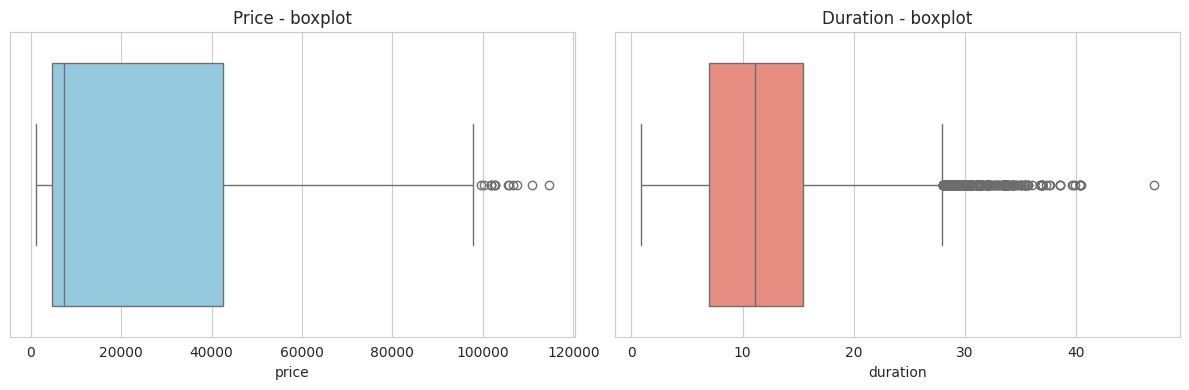

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=train['price'], ax=axes[0], color='skyblue')
axes[0].set_title('Price - boxplot')
sns.boxplot(x=train['duration'], ax=axes[1], color='salmon')
axes[1].set_title('Duration - boxplot')
plt.tight_layout()
plt.show()

In [13]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((series < lower) | (series > upper)).sum(), lower, upper

for col in ['price', 'duration']:
    n_out, low, high = iqr_outliers(train[col])
    print(f"{col}: {n_out} outliers outside [{low:.2f}, {high:.2f}] ({n_out/len(train)*100:.2f}% of rows)")

price: 14 outliers outside [-51990.50, 99125.50] (0.04% of rows)
duration: 469 outliers outside [-5.63, 28.05] (1.19% of rows)


Decision: **keeping the outliers**.

For `price`, the "outliers" are basically just Business class long-haul tickets, they're not data errors, they're a real and important part of price variation (which is literally what we're trying to predict). Same story for `duration` - the long ones are legit multi-stop flights.

Removing them would actually hurt the model since it would never learn to predict expensive tickets or long flights properly. Only would consider dropping if a value was physically impossible (e.g. negative duration or negative price), and there aren't any of those here.

In [14]:
print("Any negative durations?", (train['duration'] < 0).any())
print("Any negative/zero prices?", (train['price'] <= 0).any())

Any negative durations? False
Any negative/zero prices? False


## 6. Visualizations + insights

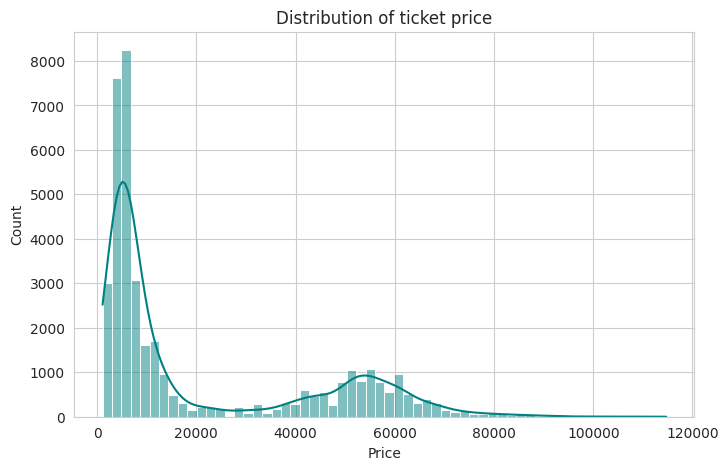

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(train['price'], bins=60, kde=True, color='teal')
plt.title('Distribution of ticket price')
plt.xlabel('Price')
plt.show()

**Insight:** price distribution is strongly right-skewed, and there's a very obvious second cluster of high prices - that's almost certainly the Business class tickets sitting way above the Economy cluster.

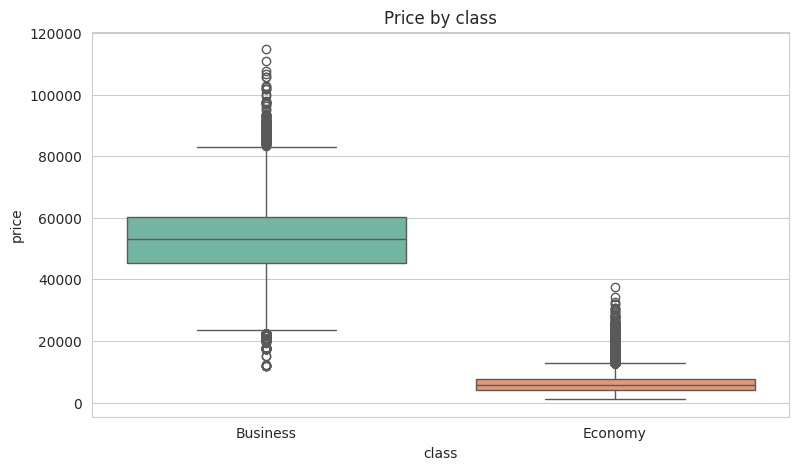

In [16]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='class', y='price', data=train, palette='Set2')
plt.title('Price by class')
plt.show()

**Insight:** confirms it - Business class tickets are massively more expensive than Economy, with almost no overlap between the two groups. `class` is going to be one of the strongest predictors here.

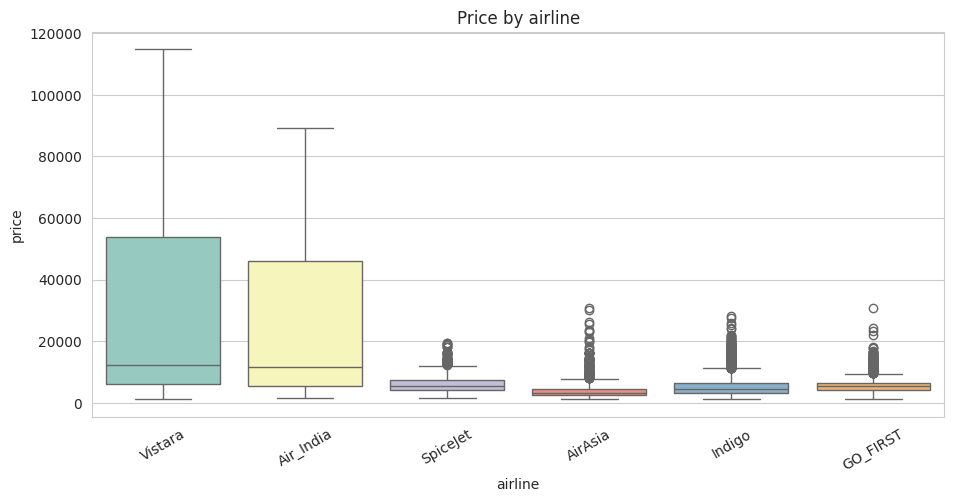

In [17]:
plt.figure(figsize=(11, 5))
sns.boxplot(x='airline', y='price', data=train, palette='Set3')
plt.title('Price by airline')
plt.xticks(rotation=30)
plt.show()

**Insight:** Vistara and Air_India have noticeably higher median prices than the budget carriers (SpiceJet, GO_FIRST, Indigo) - likely because they're the ones that actually offer Business class seats.

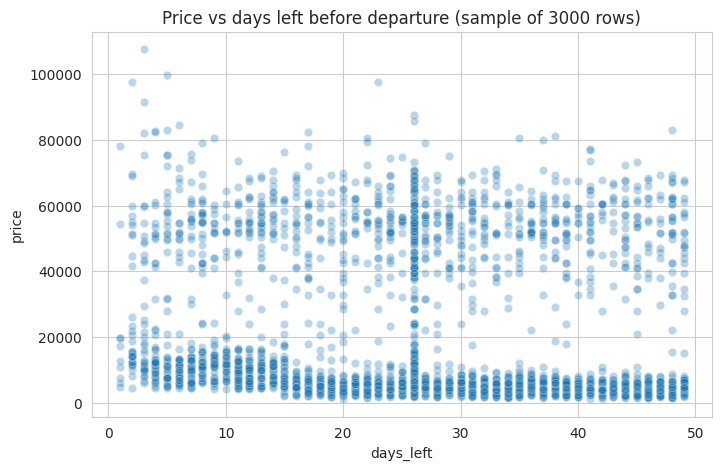

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='days_left', y='price', data=train.sample(3000, random_state=42), alpha=0.3)
plt.title('Price vs days left before departure (sample of 3000 rows)')
plt.show()

**Insight:** prices are highest when booking very close to the departure date (low `days_left`) and drop off + flatten out the further in advance you book - matches typical airline pricing behaviour.

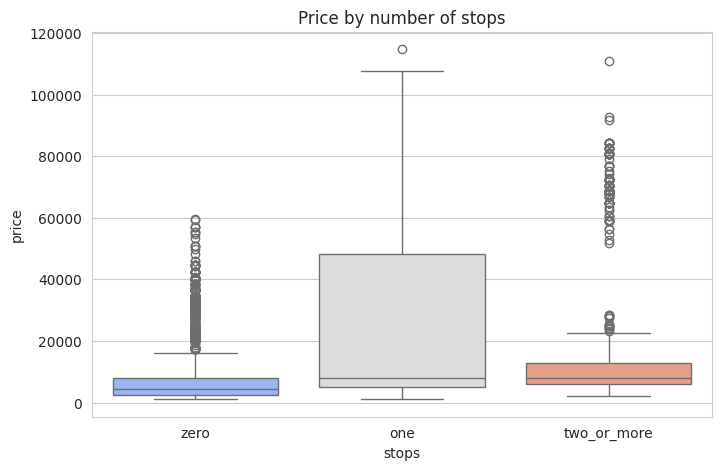

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='stops', y='price', data=train, order=['zero', 'one', 'two_or_more'], palette='coolwarm')
plt.title('Price by number of stops')
plt.show()

**Insight (bonus 4th plot):** direct (zero-stop) flights are actually cheaper on average than one-stop flights here, which is a little counterintuitive - probably because zero-stop routes tend to be the busier/more competitive short domestic routes.

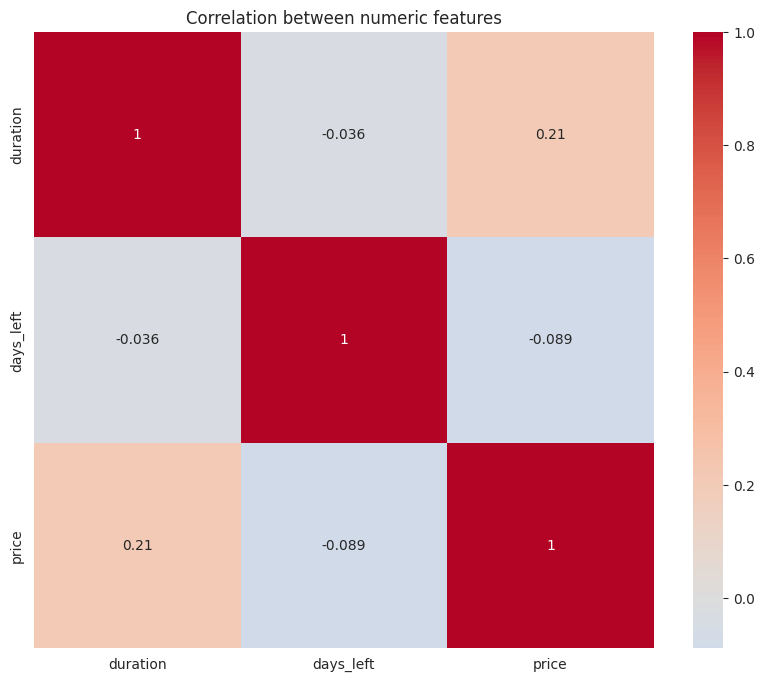

In [20]:
plt.figure(figsize=(10, 8))
corr_cols = ['duration', 'days_left', 'price']
sns.heatmap(train[corr_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation between numeric features')
plt.show()

## 7. Encoding + Scaling

- **Categorical columns** (`airline`, `source`, `departure`, `stops`, `arrival`, `destination`, `class`): all low-cardinality (max ~6 categories, `class` only has 2), so one-hot encoding is a good fit - no ordinal relationship between e.g. Delhi and Mumbai so label encoding wouldn't make sense here.
- **`flight`** column: dropping it. It's basically a flight number/code (869 unique values) which is close to an ID, one-hot encoding that would blow up the dimensionality for very little benefit given we already have `airline`.
- **Numeric columns** (`duration`, `days_left`): scaling with `StandardScaler`. Tree-based models don't strictly need this, but the linear models (Linear/Ridge/Lasso) and KNN definitely do, so scaling keeps things fair across all the models we're about to try.

In [21]:
train_features = train.drop(columns=['id', 'flight', 'price'])
test_features = test.drop(columns=['id', 'flight'])

# stack train+test together so one-hot encoding produces the exact same columns for both
combined = pd.concat([train_features, test_features], axis=0, ignore_index=True)
combined_encoded = pd.get_dummies(combined, columns=categorical_cols, drop_first=True)

n_train = train_features.shape[0]
X = combined_encoded.iloc[:n_train].reset_index(drop=True)
X_test_final = combined_encoded.iloc[n_train:].reset_index(drop=True)
y = train['price'].reset_index(drop=True)

print(X.shape, X_test_final.shape, y.shape)
X.head()

(39544, 30) (10000, 30) (39544,)


,duration,days_left,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_Chennai,source_Delhi,source_Hyderabad,source_Kolkata,source_Mumbai,departure_Early_Morning,departure_Evening,departure_Late_Night,departure_Morning,departure_Night,stops_two_or_more,stops_zero,arrival_Early_Morning,arrival_Evening,arrival_Late_Night,arrival_Morning,arrival_Night,destination_Chennai,destination_Delhi,destination_Hyderabad,destination_Kolkata,destination_Mumbai,class_Economy
0,11.08,40.0,False,False,False,False,True,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False
1,16.08,26.0,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,True
2,2.92,25.0,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True
3,1.50,22.0,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True
4,4.83,20.0,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
X_test_final[numeric_cols] = scaler.transform(X_test_final[numeric_cols])

X[numeric_cols].describe()

,duration,days_left
count,3.954400e+04,3.954400e+04
mean,1.408723e-16,7.115490e-17
std,1.000013e+00,1.000013e+00
min,-1.622923e+00,-1.971345e+00
25%,-7.211837e-01,-7.968343e-01
50%,-1.248957e-01,-1.382698e-02
75%,5.093911e-01,8.474811e-01
max,5.136469e+00,1.787090e+00


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "Validation:", X_val.shape)

Train: (31635, 30) Validation: (7909, 30)


## 8. Model building

Throwing a bunch of different regression models at this and seeing what sticks - a mix of linear models, distance-based, tree-based and boosting models.

In [24]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import time

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=1.0, random_state=42),
    'K-Nearest Neighbors': KNeighborsRegressor(n_neighbors=5),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1)
}

print(f"Training {len(models)} models...")

Training 8 models...


In [25]:
results = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    r2 = r2_score(y_val, preds)
    mae = mean_absolute_error(y_val, preds)
    elapsed = time.time() - start
    results[name] = {'model': model, 'r2': r2, 'mae': mae, 'train_time': elapsed}
    print(f"{name:22s}  R2 = {r2:.4f}   MAE = {mae:9.2f}   ({elapsed:.1f}s)")

Linear Regression       R2 = 0.9094   MAE =   4664.36   (0.0s)
Ridge Regression        R2 = 0.9094   MAE =   4664.33   (0.0s)


Lasso Regression        R2 = 0.9094   MAE =   4662.57   (0.0s)


K-Nearest Neighbors     R2 = 0.8934   MAE =   4422.56   (1.0s)
Decision Tree           R2 = 0.9381   MAE =   2699.50   (0.2s)


Random Forest           R2 = 0.9665   MAE =   2263.12   (10.8s)


Gradient Boosting       R2 = 0.9455   MAE =   3232.88   (2.5s)


XGBoost                 R2 = 0.9640   MAE =   2513.30   (0.3s)


## 9. Hyperparameter tuning

The tree ensembles (Random Forest, Gradient Boosting, XGBoost) came out on top, so tuning those three with `RandomizedSearchCV` (faster than a full grid search given the dataset size, and 5-10 random combos usually gets you close to the same result).

In [26]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=6, cv=3, scoring='r2', random_state=42, n_jobs=-1
)
rf_search.fit(X_train, y_train)
print("Best RF params:", rf_search.best_params_)
rf_tuned_preds = rf_search.best_estimator_.predict(X_val)
print("Tuned RF R2:", r2_score(y_val, rf_tuned_preds))

Best RF params: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': None}


Tuned RF R2: 0.9672823959971708


In [27]:
gb_param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2]
}

gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=gb_param_grid,
    n_iter=5, cv=3, scoring='r2', random_state=42, n_jobs=-1
)
gb_search.fit(X_train, y_train)
print("Best GB params:", gb_search.best_params_)
gb_tuned_preds = gb_search.best_estimator_.predict(X_val)
print("Tuned GB R2:", r2_score(y_val, gb_tuned_preds))

Best GB params: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}
Tuned GB R2: 0.9555352917342665


In [28]:
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=xgb_param_grid,
    n_iter=8, cv=3, scoring='r2', random_state=42, n_jobs=-1
)
xgb_search.fit(X_train, y_train)
print("Best XGB params:", xgb_search.best_params_)
xgb_tuned_preds = xgb_search.best_estimator_.predict(X_val)
print("Tuned XGB R2:", r2_score(y_val, xgb_tuned_preds))

Best XGB params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.2}
Tuned XGB R2: 0.9681411385536194


In [29]:
# add the tuned versions into the results dict so they show up in the comparison too
results['Random Forest (tuned)'] = {'model': rf_search.best_estimator_, 'r2': r2_score(y_val, rf_tuned_preds),
                                      'mae': mean_absolute_error(y_val, rf_tuned_preds), 'train_time': None}
results['Gradient Boosting (tuned)'] = {'model': gb_search.best_estimator_, 'r2': r2_score(y_val, gb_tuned_preds),
                                          'mae': mean_absolute_error(y_val, gb_tuned_preds), 'train_time': None}
results['XGBoost (tuned)'] = {'model': xgb_search.best_estimator_, 'r2': r2_score(y_val, xgb_tuned_preds),
                                'mae': mean_absolute_error(y_val, xgb_tuned_preds), 'train_time': None}

## 10. Comparing model performance

Everything side by side, sorted by validation R2.

In [30]:
comparison = pd.DataFrame({
    'R2 Score': {k: v['r2'] for k, v in results.items()},
    'MAE': {k: v['mae'] for k, v in results.items()}
}).sort_values('R2 Score', ascending=False)

comparison

,R2 Score,MAE
XGBoost (tuned),0.968141,2361.875244
Random Forest (tuned),0.967282,2261.136164
Random Forest,0.966478,2263.122580
XGBoost,0.964040,2513.296143
Gradient Boosting (tuned),0.955535,2861.207826
Gradient Boosting,0.945497,3232.875077
Decision Tree,0.938118,2699.495237
Linear Regression,0.909424,4664.362929
Ridge Regression,0.909423,4664.331642
Lasso Regression,0.909420,4662.572984


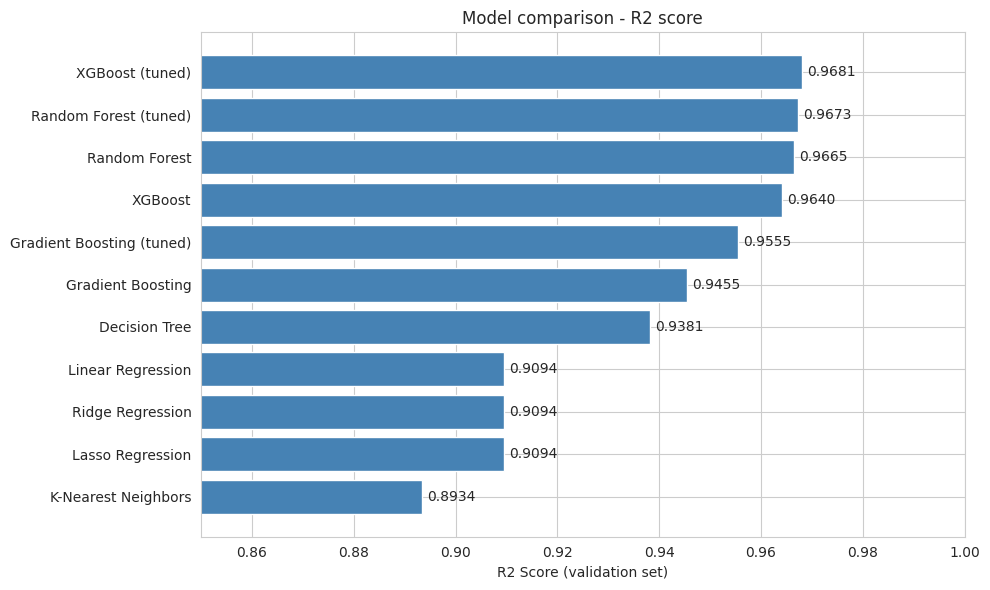

In [31]:
plt.figure(figsize=(10, 6))
comparison_sorted = comparison.sort_values('R2 Score')
plt.barh(comparison_sorted.index, comparison_sorted['R2 Score'], color='steelblue')
plt.xlabel('R2 Score (validation set)')
plt.title('Model comparison - R2 score')
plt.xlim(0.85, 1.0)
for i, v in enumerate(comparison_sorted['R2 Score']):
    plt.text(v + 0.001, i, f"{v:.4f}", va='center')
plt.tight_layout()
plt.show()

The tuned tree ensembles come out clearly ahead of the linear models, which makes sense - price doesn't have a simple linear relationship with the features (e.g. the Economy/Business jump is basically a step function, not linear). Going with the **best performing tuned model** for the final submission.

## Final submission

Picking whichever model scored highest on the validation set, refitting is not necessary since these models already saw the full `X_train`, and generating predictions for the test set.

In [32]:
best_model_name = comparison.index[0]
best_model = results[best_model_name]['model']
print("Best model:", best_model_name, "-> R2 =", results[best_model_name]['r2'])

Best model: XGBoost (tuned) -> R2 = 0.9681411385536194


In [33]:
test_predictions = best_model.predict(X_test_final)

submission = pd.DataFrame({
    'id': test['id'],
    'price': test_predictions
})

submission.to_csv('submission.csv', index=False)
submission.head()

,id,price
0,0,4196.089355
1,1,9796.267578
2,2,7075.939941
3,3,55426.179688
4,4,45832.921875


In [34]:
print("Submission file saved. Shape:", submission.shape)

Submission file saved. Shape: (10000, 2)
